# Simple Scatter Plots

Another commonly used plot type is the simple scatter plot, a close cousin of the line plot.
Instead of points being joined by line segments, here the points are represented individually with a dot, circle, or other shape.
We’ll start by setting up the notebook for plotting and importing the packages we will use:

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

## Scatter Plots with plt.plot

In the previous chapter we looked at using `plt.plot`/`ax.plot` to produce line plots.
It turns out that this same function can produce scatter plots as well (see the following figure):

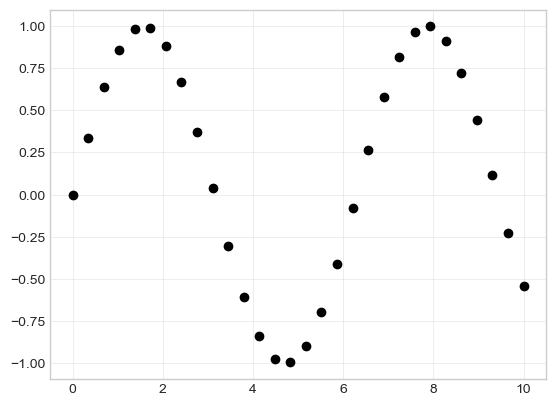

In [5]:
x = np.linspace(0, 10, 30)
y = np.sin(x)

plt.plot(x, y, 'o', color='black');

In [6]:
'--'      # 线型 — 虚线
'-.'      # 线型 — 点划线
':'       # 线型 — 点线（密集的小点连线）
'o'       # 标记 — 在每个数据点画个小圆圈
'.'       # 标记 — 在每个数据点画个小点
'^'       # 标记 — 三角形
's'       # 标记 — 正方形

's'

The third argument in the function call is a character that represents the type of symbol used for the plotting. Just as you can specify options such as `'-'` or `'--'` to control the line style, the marker style has its own set of short string codes. The full list of available symbols can be seen in the documentation of `plt.plot`, or in Matplotlib's [online documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.markers.MarkerStyle.html). Most of the possibilities are fairly intuitive, and a number of the more common ones are demonstrated here (see the following figure):

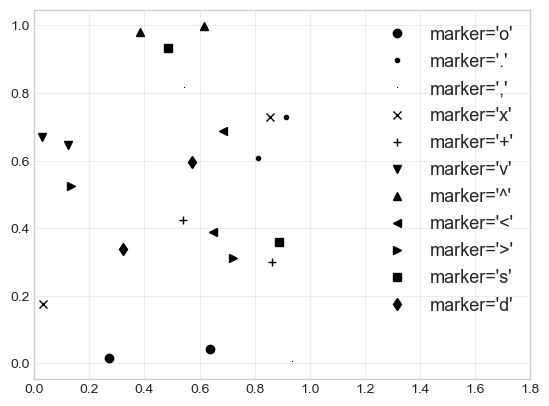

In [13]:
rng = np.random.default_rng(0) # .default_rng 创建一个随机数生成器，0 是种子（seed），保证每次运行结果一致
for marker in ['o', '.', ',', 'x', '+', 'v', '^', '<', '>', 's', 'd']:
    plt.plot(rng.random(2), rng.random(2), marker, color='black',
             label="marker='{0}'".format(marker)) # {0} 是一个占位符，会被 .format(marker) 替换成 marker 变量的值
plt.legend(numpoints=1, fontsize=13)
# numpoints=1 — 图例中每个标记旁边画几个点，默认是 1 个点，设为 2 就是只画 2 个
# fontsize=13 — 图例文字的字体大小
plt.xlim(0, 1.8);

For even more possibilities, these character codes can be used together with line and color codes to plot points along with a line connecting them (see the following figure):

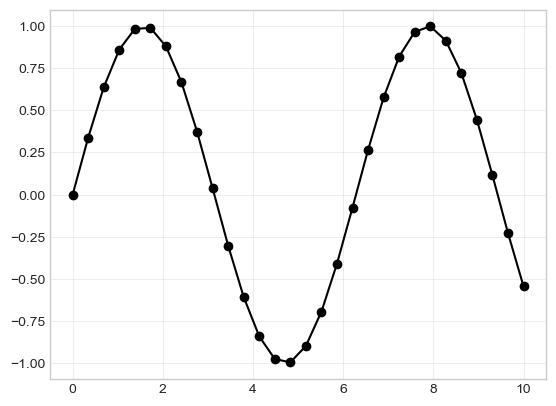

In [23]:
plt.plot(x, y, '-ok');
# - 实线，o 黑色圆点，k 黑色

Additional keyword arguments to `plt.plot` specify a wide range of properties of the lines and markers, as you can see in the following figure:

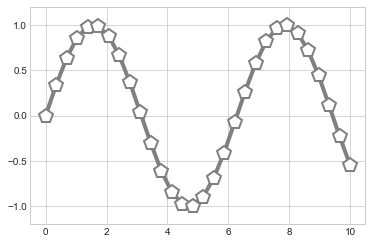

In [5]:
plt.plot(x, y, '-p', color='gray',
         markersize=15, linewidth=4,
         markerfacecolor='white',
         markeredgecolor='gray',
         markeredgewidth=2)
plt.ylim(-1.2, 1.2);

These kinds of options make `plt.plot` the primary workhorse for two-dimensional plots in Matplotlib.
For a full description of the options available, refer to the [`plt.plot` documentation](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.plot.html).

## Scatter Plots with plt.scatter

A second, more powerful method of creating scatter plots is the `plt.scatter` function, which can be used very similarly to the `plt.plot` function (see the following figure):

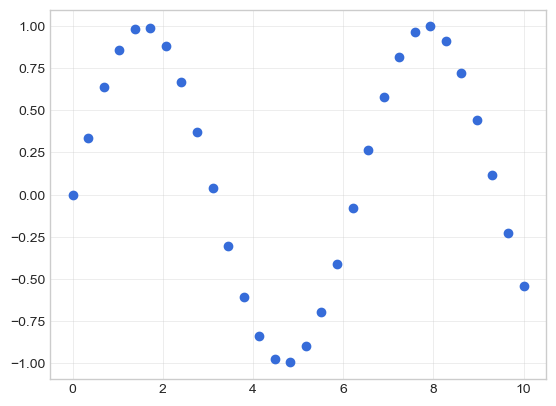

In [28]:
plt.scatter(x, y, marker='o');
# 结果等价于 plt.plot(x, y, 'o')，但plot画出来是一个整体而 scatter 可以定义每个点

The primary difference of `plt.scatter` from `plt.plot` is that it can be used to create scatter plots where the properties of each individual point (size, face color, edge color, etc.) can be individually controlled or mapped to data.

Let's show this by creating a random scatter plot with points of many colors and sizes.
In order to better see the overlapping results, we'll also use the `alpha` keyword to adjust the transparency level (see the following figure):

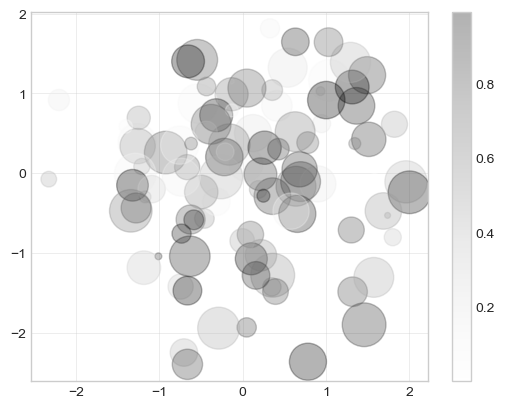

In [33]:
rng = np.random.default_rng(0)
x = rng.normal(size=100) # 不规定就是标准正态分布 (mean, std, size=n)
y = rng.standard_normal(100) # 与上方等价
colors = rng.random(100)
sizes = 1000 * rng.random(100)

plt.scatter(x, y, c=colors, s=sizes, alpha=0.3) # alpha 接收 0 到 1 之间的浮点数，控制点的透明度，0看不见，1完全不透明(默认)
plt.colorbar();  # show color scale

Notice that the color argument is automatically mapped to a color scale (shown here by the `colorbar` command), and that the size argument is given in pixels.
In this way, the color and size of points can be used to convey information in the visualization, in order to visualize multidimensional data.

For example, we might use the Iris dataset from Scikit-Learn, where each sample is one of three types of flowers that has had the size of its petals and sepals carefully measured (see the following figure):

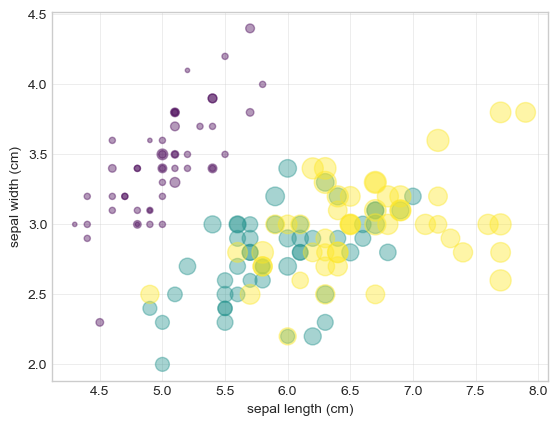

In [34]:
from sklearn.datasets import load_iris
iris = load_iris()
features = iris.data.T

plt.scatter(features[0], features[1], alpha=0.4,
            s=100*features[3], c=iris.target, cmap='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1]);

A full-color version of this plot is available in the [online version](http://github.com/jakevdp/PythonDataScienceHandbook) of the book.

We can see that this scatter plot has given us the ability to simultaneously explore four different dimensions of the data:
the (*x*, *y*) location of each point corresponds to the sepal length and width, the size of the point is related to the petal width, and the color is related to the particular species of flower.
Multicolor and multifeature scatter plots like this can be useful for both exploration and presentation of data.

## plot Versus scatter: A Note on Efficiency

Aside from the different features available in `plt.plot` and `plt.scatter`, why might you choose to use one over the other? While it doesn't matter as much for small amounts of data, as datasets get larger than a few thousand points, `plt.plot` can be noticeably more efficient than `plt.scatter`.
The reason is that `plt.scatter` has the capability to render a different size and/or color for each point, so the renderer must do the extra work of constructing each point individually.
With `plt.plot`, on the other hand, the markers for each point are guaranteed to be identical, so the work of determining the appearance of the points is done only once for the entire set of data.
For large datasets, this difference can lead to vastly different performance, and for this reason, `plt.plot` should be preferred over `plt.scatter` for large datasets.